# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [5]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st 
import math as mt

## Carregue os dados

In [6]:
# Carregue os arquivos de dados em diferentes DataFrames
df_calls = pd.read_csv('megaline_calls.csv')
df_internet = pd.read_csv('megaline_internet.csv')
df_messages = pd.read_csv('megaline_messages.csv')
df_plans = pd.read_csv('megaline_plans.csv')
df_users = pd.read_csv('megaline_users.csv')

## Prepare os dados

## Planos

In [7]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print(df_plans.info())
print(df_plans.head())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes
None
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03    

## Corrija os dados

Não há nada a ser coorrigido, plans é apenas uma tabela para referencia\
0 nulos\
0 duplicadas (visivelmente)\
snake_case esta certo

## Enriqueça os dados

In [8]:
# 1.4 TRATAMENTO PLANOS
df_plans['gb_per_month_included'] = (df_plans['mb_per_month_included'] / 1024).astype(int) # Transformando valores em GB
df_plans = df_plans[['messages_included', 'mb_per_month_included', 'gb_per_month_included', 'minutes_included',
                     'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
                     'plan_name']] # Organizando as colunas


## Usuários

In [9]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
print(df_users.info())
print(df_users.head())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB
None
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Belle

### Corrija os dados

possui nulos, mas podem ser usados com tranquilidade, pois ja foram identificados como "plano ainda em execução"\
0 Duplicados\
snake_case esta certo


### Enriqueça os dados

In [10]:
df_users['reg_date'] = pd.to_datetime(df_users['reg_date']) # Transformando valores da tabela em data
df_users['churn_date'] = pd.to_datetime(df_users['churn_date']) # Transformando valores da tabela em data
df_users['state'] = df_users['city'].str.split(', ').str[1] # Dividindo cidade de estado, selecionando a sigla do estado
df_users['city'] = df_users['city'].str.split(', ').str[0] # Dividindo cidade de estado, selecionando a cidade
df_users = df_users[['user_id', 'first_name', 'last_name', 'age', 'reg_date', 'churn_date', 'city', 'state', 'plan']] # Reposicionando as colunas

## Chamadas

In [11]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
print(df_calls.info())
print(df_calls.head())

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB
None
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


### Corrija os dados

0 Nulos\
0 Duplicados\
snake_case está correto

### Enriqueça os dados

In [12]:
df_calls['call_date'] = pd.to_datetime(df_calls['call_date']) # Transformando valores da tabela em data
df_calls['duration'] = np.ceil(df_calls['duration']).astype(int) # Arredondando valores para cima, para contar certamente todos os minutos que vão ser cobrados
df_calls['month'] = df_calls['call_date'].dt.strftime('%m') # Criando uma coluna para o mês
df_calls = df_calls[['id', 'user_id', 'call_date', 'month', 'duration']] # Organizando as colunas

## Mensagens

In [13]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
print(df_messages.info())
print(df_messages.head())

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB
None
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


### Corrija os dados

Nada a ser corrigido\
0 Nulos\
0 duplicadas\
snake_case está correto

### Enriqueça os dados

In [14]:
df_messages['message_date'] = pd.to_datetime(df_messages['message_date']) # Transformando valores da tabela em data
df_messages['month'] = df_messages['message_date'].dt.strftime('%m') # Criando uma coluna para o mês

## Internet

In [15]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
print(df_internet.info())
print(df_internet.head())

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB
None
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


### Corrija os dados

Nada a ser corrigido\
0 Nulos\
0 duplicadas\
snake_case correto

### Enriqueça os dados

In [16]:
df_internet['session_date'] = pd.to_datetime(df_internet['session_date']) # Transformando valores da tabela em data
df_internet['mb_used'] = np.ceil(df_internet['mb_used']).astype(int) # Arredondando valores para cima, para contar certamente todos os MB que vão ser cobrados
df_internet['month'] = df_internet['session_date'].dt.strftime('%m') # Criando uma coluna para o mês
df_internet = df_internet[['id', 'user_id', 'session_date', 'month', 'mb_used']] # Organizando as colunas

## Estude as condições dos planos

Foi inserido a coluna 'gb_per_month_included', com o valors de 'mb_per_month_included' divido por 1024, podendo assim auxiliar em calculos futuros

## Agregue os dados por usuário

In [17]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
df_calls_count = df_calls.groupby(['user_id', 'month'])['id'].count().reset_index()
print(df_calls_count.head())

   user_id month  id
0     1000    12  16
1     1001    08  27
2     1001    09  49
3     1001    10  65
4     1001    11  64


In [18]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
df_calls_duration = df_calls.groupby(['user_id', 'month'])['duration'].sum().reset_index() # Agrupo duraçao por usuario e mes
df_calls_duration = df_calls_duration.rename(columns={'duration': 'total_duration'}) # Renomeio a coluna duração
print(df_calls_duration.head())

   user_id month  total_duration
0     1000    12             124
1     1001    08             182
2     1001    09             315
3     1001    10             393
4     1001    11             426


In [19]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
df_messages_count = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index() # Agrupo mensagens por usuario e mes
df_messages_count = df_messages_count.rename(columns={'id': 'total_messages'}) # Renomeio a coluna mensagens
print(df_messages_count.head())

   user_id month  total_messages
0     1000    12              11
1     1001    08              30
2     1001    09              44
3     1001    10              53
4     1001    11              36


In [20]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
df_internet_consume = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index() # Agrupo gasto de mb por usuario e mes
df_internet_consume['total_gb_used'] = np.ceil(df_internet_consume['mb_used'] / 1024).astype(int) # Calculo o valor por GB
df_internet_consume = df_internet_consume.drop(columns='mb_used') # Removo a coluna de MB
print(df_internet_consume.head())

   user_id month  total_gb_used
0     1000    12              2
1     1001    08              7
2     1001    09             14
3     1001    10             22
4     1001    11             19


In [21]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
df_merged = pd.merge(df_calls_count, df_calls_duration, on=['user_id', 'month']) # Junto a contagem e duração das ligações
df_merged = pd.merge(df_merged, df_messages_count, on=['user_id', 'month']) # junto com a contagem de mensagem
df_merged = pd.merge(df_merged, df_internet_consume, on=['user_id', 'month']) # Junto com a contagem de internet
print(df_merged.head())

   user_id month  id  total_duration  total_messages  total_gb_used
0     1000    12  16             124              11              2
1     1001    08  27             182              30              7
2     1001    09  49             315              44             14
3     1001    10  65             393              53             22
4     1001    11  64             426              36             19


In [22]:
# Adicione as informações sobre o plano
df_user_plans = df_users[['user_id', 'plan']] # Pego o plano de cada usuario...
df_merged = pd.merge(df_merged, df_user_plans, on='user_id') # ...e insiro junto a tabela
df_merged = df_merged.rename(columns={'plan':'plan_name'}) # Renomeio para juntar tudo
# Junto df_plans ao df_merged para ter a informação de cada cliente em especifico
#e tiro a coluna mb_per_month_included pois ja tenho a coluna calculada em GB
df_all_clients_info = pd.merge(df_merged, df_plans, on='plan_name').drop(columns=['mb_per_month_included'])
print(df_all_clients_info.head())

   user_id month  id  total_duration  total_messages  total_gb_used plan_name  \
0     1000    12  16             124              11              2  ultimate   
1     1001    08  27             182              30              7      surf   
2     1001    09  49             315              44             14      surf   
3     1001    10  65             393              53             22      surf   
4     1001    11  64             426              36             19      surf   

   messages_included  gb_per_month_included  minutes_included  \
0               1000                     30              3000   
1                 50                     15               500   
2                 50                     15               500   
3                 50                     15               500   
4                 50                     15               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               70           7             0.01         

In [ ]:
# Calcule a receita mensal para cada usuário
# RECEITA MENSAL DE CADA USUARIO
def revenue_calc(row):
  revenue = row['usd_monthly_pay'] # Receita = ao pagamento fixo do mes

  if row['total_duration'] > row['minutes_included']: # Se o minutos usados forem maior que o disponibilizado
    extra_minutes = row['total_duration'] - row['minutes_included'] # Pegue os minutos a mais
    revenue += extra_minutes * row['usd_per_minute'] # Multiplique pelo adicional

  if row['total_messages'] > row['messages_included']: # Se as mensagens usados forem maior que o disponibilizado
    extra_messages = row['total_messages'] - row['messages_included'] # Pegue as mensagens a mais
    revenue += extra_messages * row['usd_per_message'] # Multiplique pelo adicional

  if row['total_gb_used'] > row['gb_per_month_included']: # Se o GB's usados forem maior que o disponibilizado
    extra_internet = row['total_gb_used'] - row['gb_per_month_included'] # Pegue os GB's a mais
    revenue += extra_internet * row['usd_per_gb'] # Multiplique pelo adicional

  return revenue # Retorne a receita
df_all_clients_info['revenue'] = df_all_clients_info.apply(revenue_calc, axis=1) # Insiro os valores em uma nova coluna
print(df_all_clients_info[['user_id', 'month', 'plan_name', 'revenue']].sample(10)) # Imprimo colunas especificas para melhor visualização

      user_id month plan_name  revenue
1562     1438    11      surf    50.00
1684     1472    05      surf    23.30
683      1191    05  ultimate    70.00
803      1222    07      surf   115.97
1168     1326    11      surf    36.20
33       1011    10  ultimate    70.00
1670     1467    08  ultimate    70.00
1216     1335    12      surf    41.17
1043     1285    08      surf    20.00
200      1062    07  ultimate    70.00


## Estude o comportamento do usuário

### Chamadas

<Axes: title={'center': 'Média por mês'}, xlabel='Mês', ylabel='Média de tempo(em minutos)'>

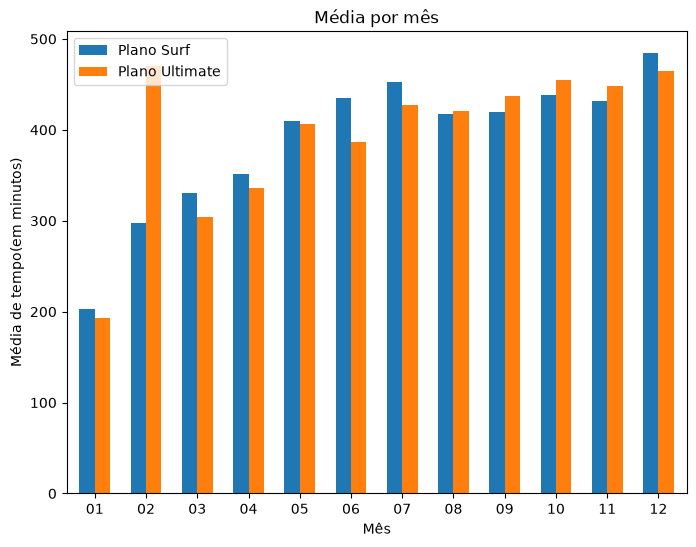

In [24]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
calls_and_plans = pd.merge(df_calls_duration, df_users[['user_id', 'plan']], on='user_id') # Junto os planos com a tabela da duração das ligações
mean_calls_per_plan = calls_and_plans.groupby(['plan', 'month'])['total_duration'].mean().reset_index() # Calculo a média de cada ligação por mes
mean_calls_per_plan = mean_calls_per_plan.rename(columns={'total_duration':'mean_by_month'}) # Renomeio a coluna
mean_calls_per_plan['mean_by_month'] = mean_calls_per_plan['mean_by_month'].astype(int) # Transformo em inteiro

#print(calls_and_plans.head())
#print()
#print(mean_calls_per_plan.head(30))
exhibition = mean_calls_per_plan.pivot(index='month', columns='plan', values='mean_by_month') # Faço um pivot para a exibição
exhibition = exhibition.rename(columns={'surf': 'Plano Surf', 'ultimate': 'Plano Ultimate'}) # Mudo as legendas
exhibition.columns.name = None # Tiro no titulo das legendas, e termino fazendo o grafico abaixo:
exhibition.plot(kind='bar',
                xlabel='Mês',
                ylabel='Média de tempo(em minutos)',
                figsize=(8, 6),
                width=0.6,
                rot=0,
                title='Média por mês')

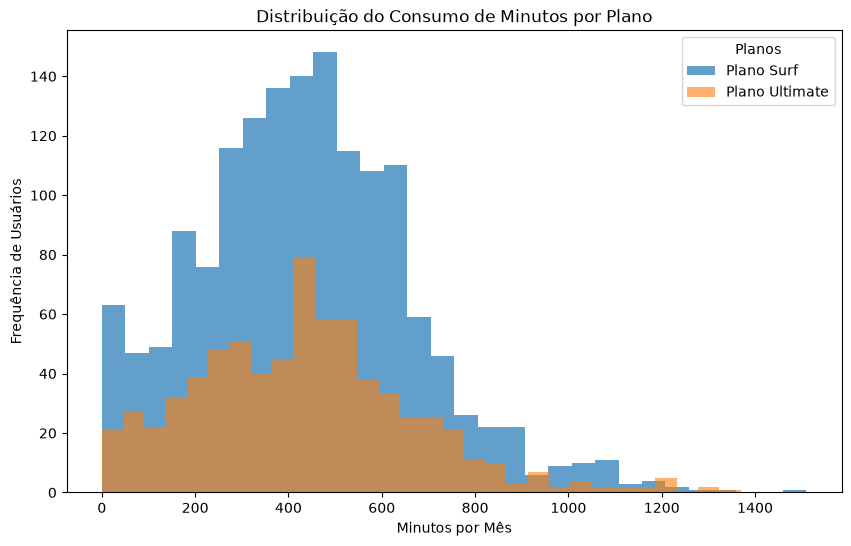

In [25]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
# Separo os minutos de cada plano
surf_minutes = calls_and_plans[calls_and_plans['plan'] == 'surf']['total_duration']
ultimate_minutes = calls_and_plans[calls_and_plans['plan'] == 'ultimate']['total_duration']

# Gero o histograma de cada um
surf_minutes.plot(kind='hist', bins=30, alpha=0.7, label='Plano Surf', figsize=(10, 6))
ultimate_minutes.plot(kind='hist', bins=30, alpha=0.6, label='Plano Ultimate')

# Aperfeiçoo ele
plt.title('Distribuição do Consumo de Minutos por Plano')
plt.xlabel('Minutos por Mês')
plt.ylabel('Frequência de Usuários')
plt.legend(title='Planos')
plt.show()

[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [26]:
# Calcule a média e a variância da duração mensal das chamadas
calls_stats = calls_and_plans.groupby('plan')['total_duration'].agg(['mean', 'var']).reset_index() # Agrupo a duraçao das ligaçoes por plano e ja agrego com a média e variancia
calls_stats.columns = ['Plano', 'Média', 'Variância'] # Renomeio para velhor visualização
print(calls_stats)

      Plano       Média     Variância
0      surf  436.519741  52571.063243
1  ultimate  434.676017  56573.632247


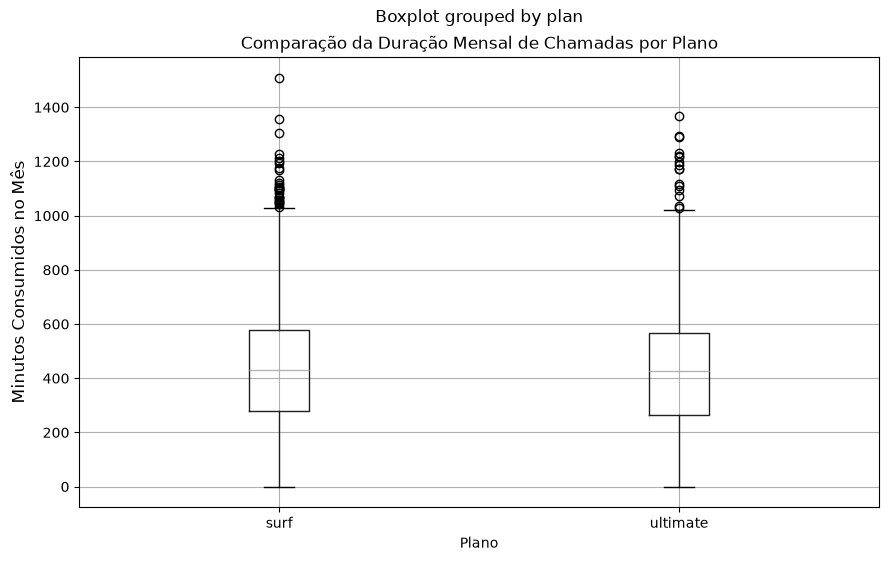

In [27]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
calls_and_plans.boxplot(column='total_duration', by='plan', figsize=(10, 6)) # Gero um diagrama de caixa
plt.title('Comparação da Duração Mensal de Chamadas por Plano')
plt.xlabel('Plano')
plt.ylabel('Minutos Consumidos no Mês', fontsize=12)
plt.show()

Conclui-se que a média e a mediana entre ambos os planos são quase identicas, a diferença é que, quem possui o plano surf, está proximo de exceder o limite.\
O diagrama de caixa quase chega em 600 minutos, o que indica que uma parte significativa dos assinantes do plano surf, execedem o limite, assim pagando tarifas adicionais\
Já os usuarios do ultimate mal chegam a metade do limite, onde possuimos um outlier a quase 1500, portanta, eles nao geram receitas adicionais

### Mensagens

        plan month  mean_by_month
0       surf    01             21
1       surf    02             21
2       surf    03             21
3       surf    04             24
4       surf    05             33
5       surf    06             33
6       surf    07             35
7       surf    08             37
8       surf    09             39
9       surf    10             42
10      surf    11             40
11      surf    12             48
12  ultimate    01             20
13  ultimate    02             25
14  ultimate    03             34
15  ultimate    04             28
16  ultimate    05             44
17  ultimate    06             36
18  ultimate    07             41
19  ultimate    08             47
20  ultimate    09             45
21  ultimate    10             46
22  ultimate    11             47
23  ultimate    12             53


<Axes: title={'center': 'Média por mês'}, xlabel='Mês', ylabel='Média de mensagens'>

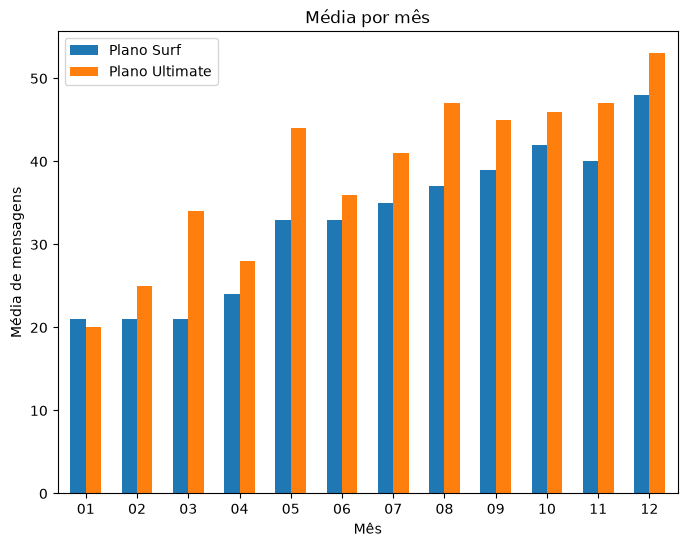

In [28]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
messages_and_plans = pd.merge(df_messages_count, df_users[['user_id', 'plan']], on='user_id') # Junto os planos com a tabela da quantidade de mensagens
mean_messages_per_plans = messages_and_plans.groupby(['plan', 'month'])['total_messages'].mean().reset_index() # Calculo a média da quantidade de mensagens por mes
mean_messages_per_plans = mean_messages_per_plans.rename(columns={'total_messages':'mean_by_month'}) # Renomeio a coluna
mean_messages_per_plans['mean_by_month'] = mean_messages_per_plans['mean_by_month'].astype(int) # Transformo em inteiro
print(mean_messages_per_plans.head(24))

exhibition_messages = mean_messages_per_plans.pivot(index='month', columns='plan', values='mean_by_month') # Faço um pivot para a exibição
exhibition_messages = exhibition_messages.rename(columns={'surf': 'Plano Surf', 'ultimate': 'Plano Ultimate'}) # Mudo as legendas
exhibition_messages.columns.name = None # Tiro no titulo das legendas, e termino fazendo o grafico abaixo:
exhibition_messages.plot(kind='bar', xlabel='Mês',ylabel='Média de mensagens', figsize=(8, 6), width=0.6, rot=0, title='Média por mês')

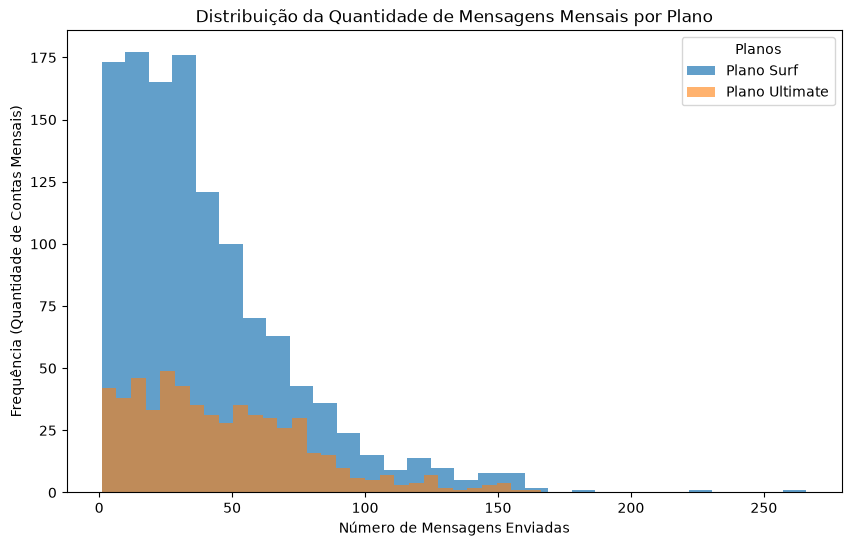

In [29]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
# Junto a tabela de consumo de internet com os usuarios, pego apenas o plano de cada e removo o mes, cuja coluna nao vou usar
internet_usage_per_month = pd.merge(df_internet_consume, df_users[['user_id', 'plan']], on='user_id')
# Agrupo primeiro por plano, depois por usuario, assim a tabela fica dividida de maneira mais uniforme
internet_usage_per_plan = internet_usage_per_month.groupby(['plan', 'user_id'])['total_gb_used'].sum().reset_index()

# Separo as mensagens de cada plano
surf_messages = messages_and_plans[messages_and_plans['plan'] == 'surf']['total_messages']
ultimate_messages = messages_and_plans[messages_and_plans['plan'] == 'ultimate']['total_messages']

# Gero o histograma de cada um
surf_messages.plot(kind='hist', bins=30, alpha=0.7, label='Plano Surf', figsize=(10, 6))
ultimate_messages.plot(kind='hist', bins=30, alpha=0.6, label='Plano Ultimate')

# Aperfeiçoo ele
plt.title('Distribuição da Quantidade de Mensagens Mensais por Plano')
plt.xlabel('Número de Mensagens Enviadas')
plt.ylabel('Frequência (Quantidade de Contas Mensais)')
plt.legend(title='Planos')
plt.show()

In [30]:
messages_stats = messages_and_plans.groupby('plan')['total_messages'].agg(['mean','var']).reset_index() # Agrupo a quantida de mensagens por plano e ja agrego com a média e variancia
messages_stats.columns = ['Plano', 'Média de Mensagens', 'Variância'] # Renomeio para velhor visualização
print(messages_stats)

      Plano  Média de Mensagens    Variância
0      surf           40.109656  1091.344231
1  ultimate           46.296233  1085.183108


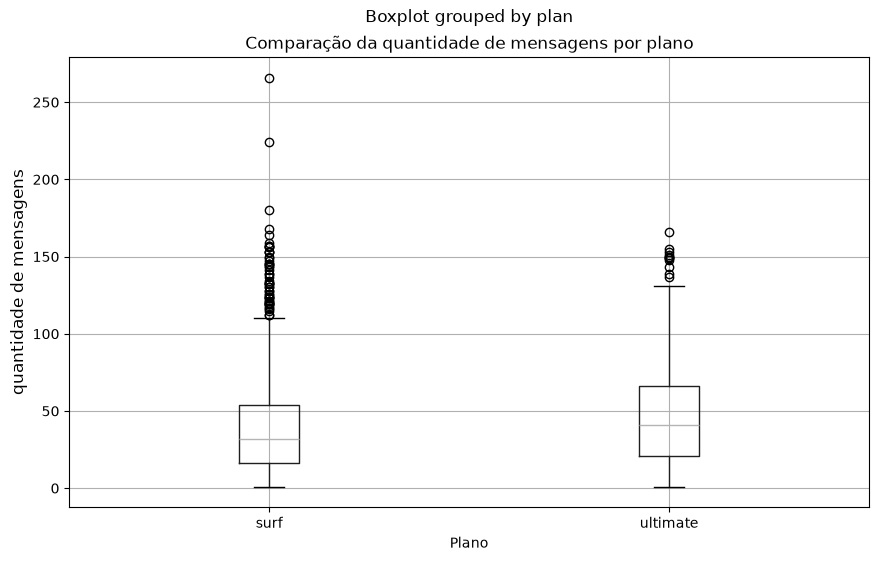

In [31]:
messages_and_plans.boxplot(column='total_messages', by='plan', figsize=(10, 6)) # Gero um diagrama de caixa
plt.title('Comparação da quantidade de mensagens por plano')
plt.xlabel('Plano')
plt.ylabel('quantidade de mensagens', fontsize=12)
plt.show()

Conclui-se que a média e a mediana de mensagens é quase igual. No entanto, a variância e o desvio padrão são altos (cerca de 33 mensagens de desvio padrão), mostrando que o comportamento dos usuários é muito disperso nos dois grupos\
A respeito do limite de mensagens, o plano surf sempre estoura ele, e passa das 100 mensagens, obtendo outliers de mais de 250 mensagens, ja o pessoal do Ultimate não chega a 200 no total
Por fim assinantes do plano surf geram muita mais tarifas adicionais do que os assinantes do plano ultimate

### Internet

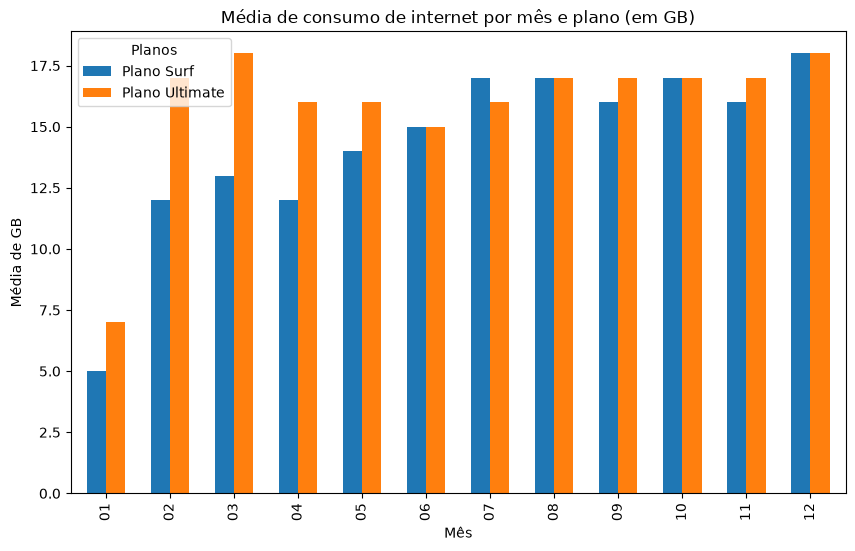

In [32]:
mean_internet_per_month = internet_usage_per_month.groupby(['plan', 'month'])['total_gb_used'].mean().reset_index() # Calculo a média de internet gasta por plano e por mes
mean_internet_per_month['total_gb_used'] = mean_internet_per_month['total_gb_used'].astype(int) # Converto a media em inteiro
mean_internet_per_month = mean_internet_per_month.rename(columns={'total_gb_used':'mean_gb_used'}) # Renomeio para melhor leitura
###print(mean_internet_per_month.head())

exhibition_net = mean_internet_per_month.pivot(index='month', columns='plan', values='mean_gb_used') # Começo a crição de um grafico de barras
exhibition_net = exhibition_net.rename(columns={'surf': 'Plano Surf', 'ultimate': 'Plano Ultimate'})
exhibition_net.columns.name = None

exhibition_net.plot(kind='bar', figsize=(10, 6), width=0.6)
plt.title('Média de consumo de internet por mês e plano (em GB)')
plt.xlabel('Mês')
plt.ylabel('Média de GB')
plt.legend(title='Planos')
plt.show()

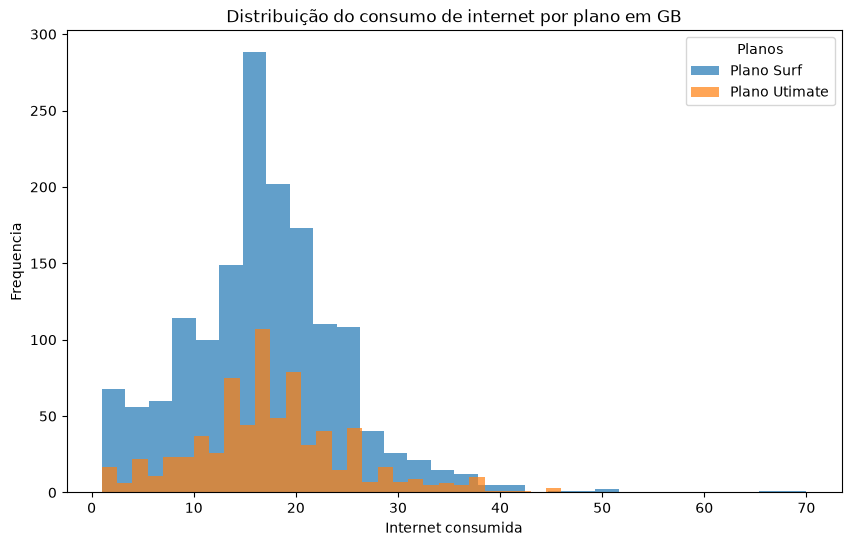

In [33]:
# Criando um histograma
# Separo o gasto de cada plano
surf_net = internet_usage_per_month[internet_usage_per_month['plan'] == 'surf']['total_gb_used']
ultimate_net = internet_usage_per_month[internet_usage_per_month['plan'] == 'ultimate']['total_gb_used']

# Gero um histograma de cada um
surf_net.plot(kind='hist', bins=30, alpha=0.7, label='Plano Surf', figsize=(10,6))
ultimate_net.plot(kind='hist', bins=30, alpha=0.7, label='Plano Utimate')

# Aperfeiçoo
plt.title('Distribuição do consumo de internet por plano em GB')
plt.xlabel('Internet consumida')
plt.ylabel('Frequencia')
plt.legend(title='Planos')
plt.show()

In [34]:
internet_stats = internet_usage_per_month.groupby('plan')['total_gb_used'].agg(['mean', 'var']).reset_index() # Agrupo a quantidade de internet gasta por plano e ja agrego com a média e variancia
internet_stats.columns = ['Plano', 'Média de Internet', 'Variância'] # Renomeio para melhor visualização
print(internet_stats)

      Plano  Média de Internet  Variância
0      surf          16.845315  59.541246
1  ultimate          17.358832  58.603651


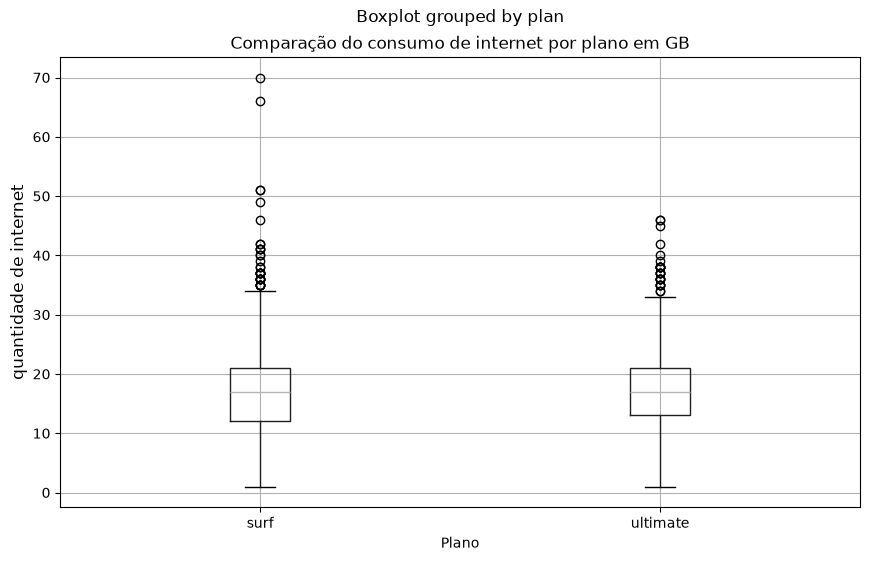

In [35]:
# Gero um boxplot
internet_usage_per_month.boxplot(column='total_gb_used', by='plan', figsize=(10, 6)) # Gero um diagrama de caixa
plt.title('Comparação do consumo de internet por plano em GB')
plt.xlabel('Plano')
plt.ylabel('quantidade de internet', fontsize=12)
plt.show()

A média demonstra que ambos os planos usam a mesma quantidade, 17 GB, o que nao gera diferença entre o plano mais caro e o mais barato, a maior parte usar entre 13 a 21 GB por mes\
Sabendo que a mediana é 17, pode-se afirmar que a maior parte das pessoas do plano Surf geram receitas adicionais pois ultrapassam o limite mensal\
Em relação aos outliers, temos usuarios do plano surf que chegaram a consumir 70GB em um mes, mas em contra partida, uma minuscula parcela dos usuarios do plano Ultimate gastam mais que 40GB

## Receita

In [36]:
df_revenue = df_all_clients_info[['user_id', 'month', 'plan_name', 'revenue']].reset_index().drop(columns='index') # Puxo exatamente o que eu preciso
df_revenue = df_revenue.rename(columns={'plan_name':'plan'})

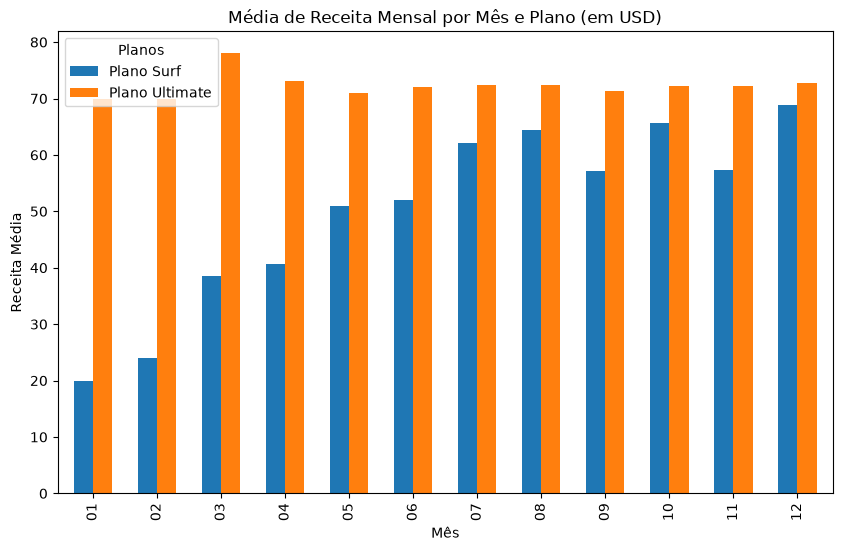

In [37]:
# Grafico de barras com a média
mean_revenue_month = df_revenue.groupby(['plan', 'month'])['revenue'].mean().reset_index() # Agrupo a média da receita por plano e mes
exhibition_rev = mean_revenue_month.pivot(index='month',columns='plan',values='revenue') # crio um pivot
exhibition_rev = exhibition_rev.rename(columns={'surf': 'Plano Surf', 'ultimate': 'Plano Ultimate'}) # Renomeio a legenda
exhibition_rev.columns.name = None

exhibition_rev.plot(kind='bar', figsize=(10,6), width=0.6) # Gero o grafico de barras
plt.title('Média de Receita Mensal por Mês e Plano (em USD)')
plt.xlabel('Mês')
plt.ylabel('Receita Média')
plt.legend(title='Planos')
plt.show()

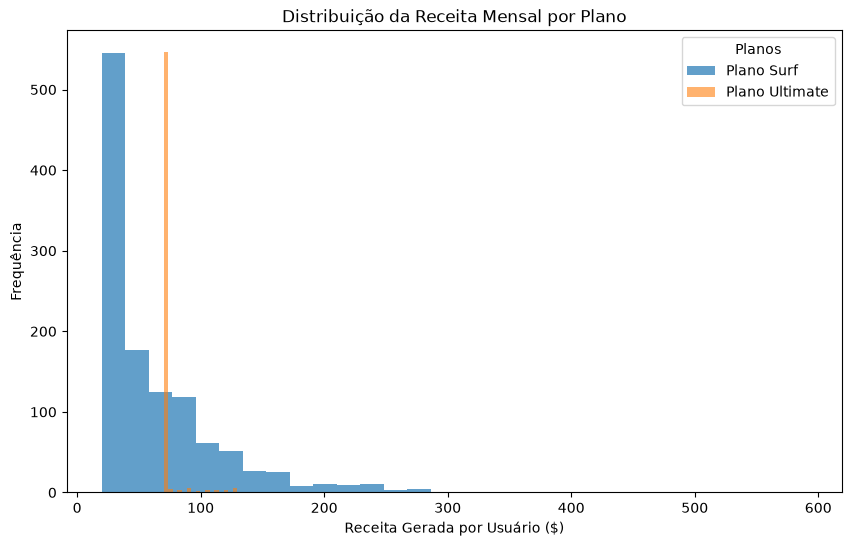

In [38]:
# Histograma
# Separo as receitas de cada plano
surf_rev = df_revenue[df_revenue['plan'] == 'surf']['revenue']
ultimate_rev = df_revenue[df_revenue['plan'] == 'ultimate']['revenue']

# Gero um histograma pra cada
surf_rev.plot(kind='hist', bins=30, alpha=0.7, label='Plano Surf', figsize=(10, 6))
ultimate_rev.plot(kind='hist', bins=30, alpha=0.6, label='Plano Ultimate')

# Aperfeiçoo ele
plt.title('Distribuição da Receita Mensal por Plano')
plt.xlabel('Receita Gerada por Usuário ($)')
plt.ylabel('Frequência')
plt.legend(title='Planos')
plt.show()

In [39]:
# Media e Variancia
rev_stats = df_revenue.groupby('plan')['revenue'].agg(['mean', 'var']).reset_index()
rev_stats.columns = ['Plano', 'Média de Receita', 'Variância']
print(rev_stats)

      Plano  Média de Receita    Variância
0      surf         60.526008  2880.733037
1  ultimate         72.272884   124.700492


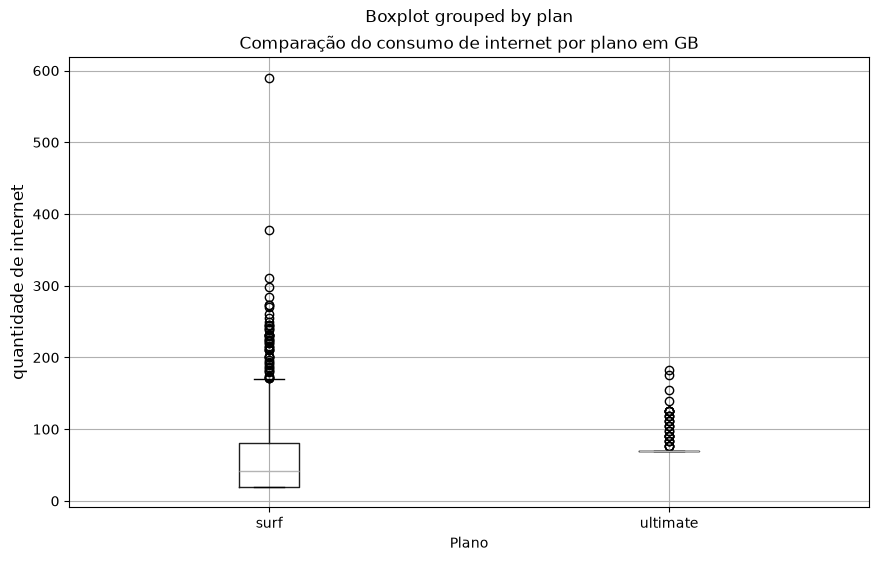

In [40]:
rev_stats = df_revenue.groupby('plan')['revenue'].agg(['mean', 'var']).reset_index()
rev_stats.columns = ['Plano', 'Média de Receita', 'Variancia']
###print(rev_stats)

df_revenue.boxplot(column='revenue', by='plan', figsize=(10, 6))
plt.title('Comparação do consumo de internet por plano em GB')
plt.xlabel('Plano')
plt.ylabel('quantidade de internet', fontsize=12)
plt.show()

Depois dos calculos realizados com a receita, observa-se que o pessoal do surf esta pagando em média 60 USD, basicamente o triplo da mensalidade fixa, isso acontece devido a quantidade de tarifas adicionais que eles pagam por mes, por estourar os limites.\
Pelo estudo da variancia, a diferença é gritante on aponta que alguns clientes estao pagando valores absurdos. É possivel observar isso com o diagrama de caixa, onde mostras que um outlier chegou a pagar quase 600 USD, enquanto os outliers do ultimate nao chegam a 200 USD.\
Outro detalhe a se falar é sobre a distribuição dos clientes de cada plano, sabendo que a média da receita do surf é 60 USD, pode-se afirmar que grande parte dos cliente do surf ultrapassam os limites, comparado ao pessoal do ultimate, quase todos os clientes pagam 70 USD, ou seja, nao ultrapassam seus limites.\
Portanta, o plano surf gera muito mais receita do que o plano ultimate, porém isso de vem ao fato de que os clientes caem em um tipo de "armadilha", achando que os 20 USD são baratos, mas o consumo real deles, os faz pagar bem mais caro. 

## Teste hipóteses estatísticas

In [41]:
# Teste as hipóteses
# Hipótese Nula (H0): A receita média dos usuários dos planos Ultimate e Surf é igual.
# Hipótese Alternativa (H1): A receita média dos usuários dos planos Ultimate e Surf é diferente.
# As amostras serão surf_rev e ultimate_rev

alpha = 0.05 # Nivel de significancia

results = st.ttest_ind(surf_rev, ultimate_rev, equal_var=False)
print(f'p-value: {results.pvalue}')
if results.pvalue < alpha:
  print("Rejeitamos a hipótese nula: A receita média dos planos é significativamente diferente.")
else:
  print("Não devemos rejeitar a hipótese nula: Não há evidências de que as receitas médias sejam diferentes.")

p-value: 9.404275461578475e-13
Rejeitamos a hipótese nula: A receita média dos planos é significativamente diferente.


In [42]:
df_revenue_city = df_revenue.merge(df_users[['user_id', 'state']], on='user_id', how='left')

In [43]:
# Teste as hipóteses
# Obtendo as amostras
df_nynj_region = df_revenue_city[df_revenue_city['state'] == 'NY-NJ-PA MSA']['revenue']
df_other_regions = df_revenue_city[df_revenue_city['state'] != 'NY-NJ-PA MSA']['revenue']

results_city = st.ttest_ind(df_nynj_region, df_other_regions, equal_var=False)
print(f"p-value: {results_city.pvalue}")

if results_city.pvalue < alpha:
    print("Rejeitamos a hipótese nula: A receita média da região NY-NJ é significativamente diferente das outras.")
else:
    print("Não devemos rejeita a hipótese nula: Não há evidências de que a receita de NY-NJ difira do resto.")

p-value: 0.004664761210704847
Rejeitamos a hipótese nula: A receita média da região NY-NJ é significativamente diferente das outras.


### Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes
p-value: 5.756661975640558e-13\
Rejeitamos a hipótese nula: A receita média dos planos é significativamente diferente.

### Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões
p-value: 0.004477811025531861\
Rejeitamos a hipótese nula: A receita média da região NY-NJ é significativamente diferente das outras.

## Conclusão geral

1.Processamento e Limpeza dos Dados
    Dos dados carregados, foram separados os meses, para melhorar calculos futuros, e posteriormente unificados em df_all_clients_info, onde podemiamos obter informações de cada cliente e seus devidos planos
    Durante o processamento, os numeros de GB e minutos foram arredondados para cima para compor as regras difinidas pelas operadora
    
2.Comportamento dos Usuários
    A analise dos usuarios revelou que a média de internet gastam em ambos os planos é praticamente identica, sabendo que mediana entre eles é 17GB, isso diz que a maior parte dos usuarios do plano surf estouram o limite de internet mensal, assim gerando grandes quantidades de tarifas adicionais
    
3.Análise de Receita e Lucratividade
    Ao analisar as receitas, nota-se que, pelo gasto excessivo dos usuarios do plano surf, eles pagam 3 vezes o valor da cobrança fixa, comparado ao pessoal do Ultimate, que o valor pago em média é muito proximo do valor fixo (70 USD).
    Também nota-se uma varianacia muito grande entre os usuarios do plano surf, onde ja chegaram a gastar quase 600 em um unicos mes.
    
4.Testes de Hipóteses Estatísticas
    O teste t da primeira hipotese rejeitou a hipótese nula. Fica provado com segurança estatística que as receitas médias dos planos Surf e Ultimate são significativamente diferentes, com o plano Ultimate ainda gerando mais receita por usuário na média geral
    já a hipótese 2 o teste estatístico também rejeitou a hipótese nula. Isso comprova que os usuários da região metropolitana de NY-NJ possuem um comportamento de faturamento estatisticamente diferente das demais regiões do país.